In [1]:
import scanpy as sc
import harmonypy as hm

In [2]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/SmoNull_Brain_system.h5ad")


In [3]:
# Cleaning up some variables that will not be used ever
del adata.obsm["X_umap"]
del adata.uns["log1p"]

In [4]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features'
    uns: 'ClusterSystem_colors'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'

# log1p Normalized - Harmony Integration 


In [5]:
adata.X = adata.layers["log1p_norm"]
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="Library.ident")


In [6]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'ClusterSystem_colors', 'hvg'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'

In [7]:
sc.pp.scale(adata) 
sc.pp.pca(adata)

/home/yubin/.conda/envs/scRNAseq_python/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


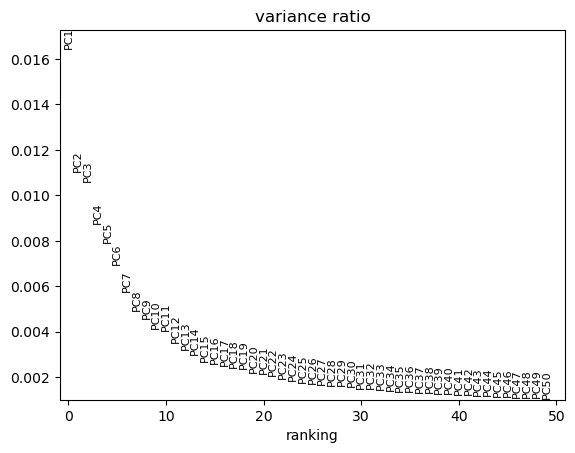

In [8]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=False)

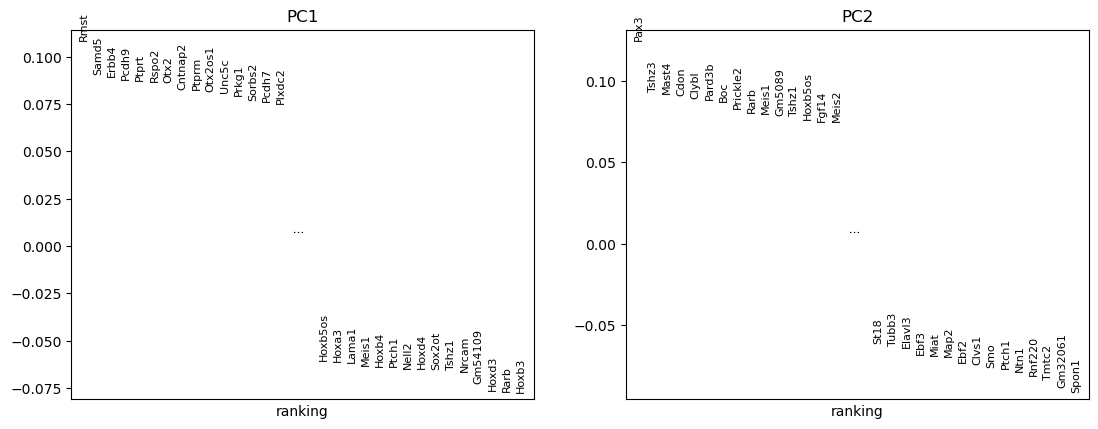

In [9]:
sc.pl.pca_loadings(adata, components = [1,2], show = True)

In [10]:
# Storing only the top 13 PCs and renaming variable for better identification
adata.obsm["X_pca_log1p"] = adata.obsm["X_pca"][:, :13]
del adata.obsm["X_pca"]

In [11]:
# Renaming some other pc and highly variable gene variables for better identification
adata.var["highly_variable_log1p"] = adata.var["highly_variable"]
del adata.var["highly_variable"]
adata.var["highly_variable_nbatches_log1p"] = adata.var["highly_variable_nbatches"]
del adata.var["highly_variable_nbatches"]
adata.var["highly_variable_intersection_log1p"] = adata.var["highly_variable_intersection"]
del adata.var["highly_variable_intersection"]

In [12]:
# Perform Harmony integration on log1p normalized data
sc.external.pp.harmony_integrate(adata, key="Library.ident", max_iter_harmony=20, adjusted_basis="X_pca_harmony_log1p", basis = "X_pca_log1p")

2026-03-06 18:58:44,003 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-06 18:58:46,751 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-06 18:58:46,880 - harmonypy - INFO - Iteration 1 of 20
2026-03-06 18:58:54,514 - harmonypy - INFO - Iteration 2 of 20
2026-03-06 18:59:02,221 - harmonypy - INFO - Iteration 3 of 20
2026-03-06 18:59:09,813 - harmonypy - INFO - Iteration 4 of 20
2026-03-06 18:59:17,476 - harmonypy - INFO - Iteration 5 of 20
2026-03-06 18:59:24,991 - harmonypy - INFO - Iteration 6 of 20
2026-03-06 18:59:32,617 - harmonypy - INFO - Iteration 7 of 20
2026-03-06 18:59:35,394 - harmonypy - INFO - Converged after 7 iterations


In [13]:
adata 

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p'
    uns: 'ClusterSystem_colors', 'hvg', 'pca'
    obsm: 'X_pca_log1p', 'X_pca_harmony_log1p'
    varm: 'PCs'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'

In [14]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony_log1p", key_added="neighbors_log1p")

/home/yubin/.conda/envs/scRNAseq_python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
sc.tl.umap(adata, neighbors_key="neighbors_log1p", key_added="X_umap_log1p")

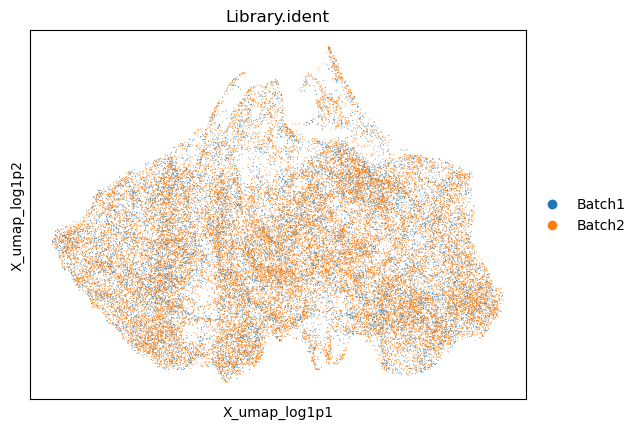

In [16]:
sc.pl.embedding(adata, basis = "X_umap_log1p", color = "Library.ident", size = 2)